# Fair Price AZ: used and new phone EDA

Train on both conditions. Select by used-only MAE. Report used/new holdout errors separately.
This notebook reads cleaned candidates and uses the same analysis as `python -m analysis.eda`.
Run cleaning first after collection. Prices are seller asking prices, not completed sales.


In [1]:
from pathlib import Path
import json
import sys
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "analysis").is_dir():
    ROOT = ROOT.parent
if not (ROOT / "analysis").is_dir():
    raise RuntimeError("Open the notebook from the project or notebooks directory")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from analysis.eda import run, table

summary = run(ROOT / "data/processed/candidates.jsonl", ROOT / "reports/eda")
print(f"Candidates: {summary['candidates']} | Used: {summary['used']} | New: {summary['new']}")


Candidates: 1267 | Used: 532 | New: 735


In [2]:
rows = [json.loads(line) for line in (ROOT / "data/processed/candidates.jsonl").read_text().split("\n") if line.strip()]
df = pd.DataFrame(rows)
print(table(pd.DataFrame(summary["prices_by_condition"])))


| condition | count | minimum | median | mean | maximum |
| --- | --- | --- | --- | --- | --- |
| new | 735 | 59.0 | 1519.0 | 1601.5 | 6999.0 |
| used | 532 | 50.0 | 615.0 | 839.3 | 3419.0 |


## Coverage by model and condition

Counts include both conditions. Different model mixes mean average new/used prices do not directly measure depreciation.


In [3]:
coverage = pd.crosstab([df.brand, df.model], df.condition).reindex(columns=["used", "new"], fill_value=0)
coverage["total"] = coverage.sum(axis=1)
print(table(coverage.sort_values("total", ascending=False).head(20).reset_index()))
print("\nDistinct models:", summary["distinct_models"])
print("Used models:", summary["distinct_used_models"], "| New models:", summary["distinct_new_models"])


| brand | model | used | new | total |
| --- | --- | --- | --- | --- |
| Apple | iPhone 17 Pro Max | 23 | 67 | 90 |
| Apple | iPhone 17 Pro | 17 | 54 | 71 |
| Samsung | Galaxy S26 Ultra | 0 | 40 | 40 |
| Apple | iPhone Air | 4 | 36 | 40 |
| Apple | iPhone 13 | 23 | 12 | 35 |
| Apple | iPhone 15 | 12 | 23 | 35 |
| Apple | iPhone 16 Pro | 25 | 6 | 31 |
| Apple | iPhone 17 | 2 | 28 | 30 |
| Apple | iPhone 15 Pro | 22 | 6 | 28 |
| Apple | iPhone 16 Pro Max | 19 | 7 | 26 |
| Apple | iPhone 14 | 15 | 11 | 26 |
| Apple | iPhone 16 | 9 | 16 | 25 |
| Apple | iPhone 15 Pro Max | 17 | 7 | 24 |
| Xiaomi | Redmi 15C | 2 | 21 | 23 |
| Samsung | Galaxy A17 | 2 | 20 | 22 |
| Samsung | Galaxy S25 Ultra | 4 | 17 | 21 |
| Samsung | Galaxy A57 5G | 1 | 19 | 20 |
| Apple | iPhone 11 | 19 | 0 | 19 |
| Apple | iPhone 13 Pro | 18 | 0 | 18 |
| Samsung | Galaxy S26 | 1 | 17 | 18 |

Distinct models: 263
Used models: 179 | New models: 136


In [4]:
print(table(pd.DataFrame(summary["missingness"])))


| field | all_missing_pct | new_missing_pct | used_missing_pct |
| --- | --- | --- | --- |
| brand | 0.0 | 0.0 | 0.0 |
| model | 0.0 | 0.0 | 0.0 |
| storage_gb | 12.6 | 17.3 | 6.2 |
| ram_gb | 13.8 | 17.3 | 9.0 |
| condition | 0.0 | 0.0 | 0.0 |
| city | 0.0 | 0.0 | 0.0 |
| seller_type | 35.6 | 8.6 | 72.9 |
| description | 1.5 | 1.1 | 2.1 |
| photo_count | 0.0 | 0.0 | 0.0 |
| year | 100.0 | 100.0 | 100.0 |
| has_box | 100.0 | 100.0 | 100.0 |
| has_warranty | 100.0 | 100.0 | 100.0 |
| posted_date | 100.0 | 100.0 | 100.0 |


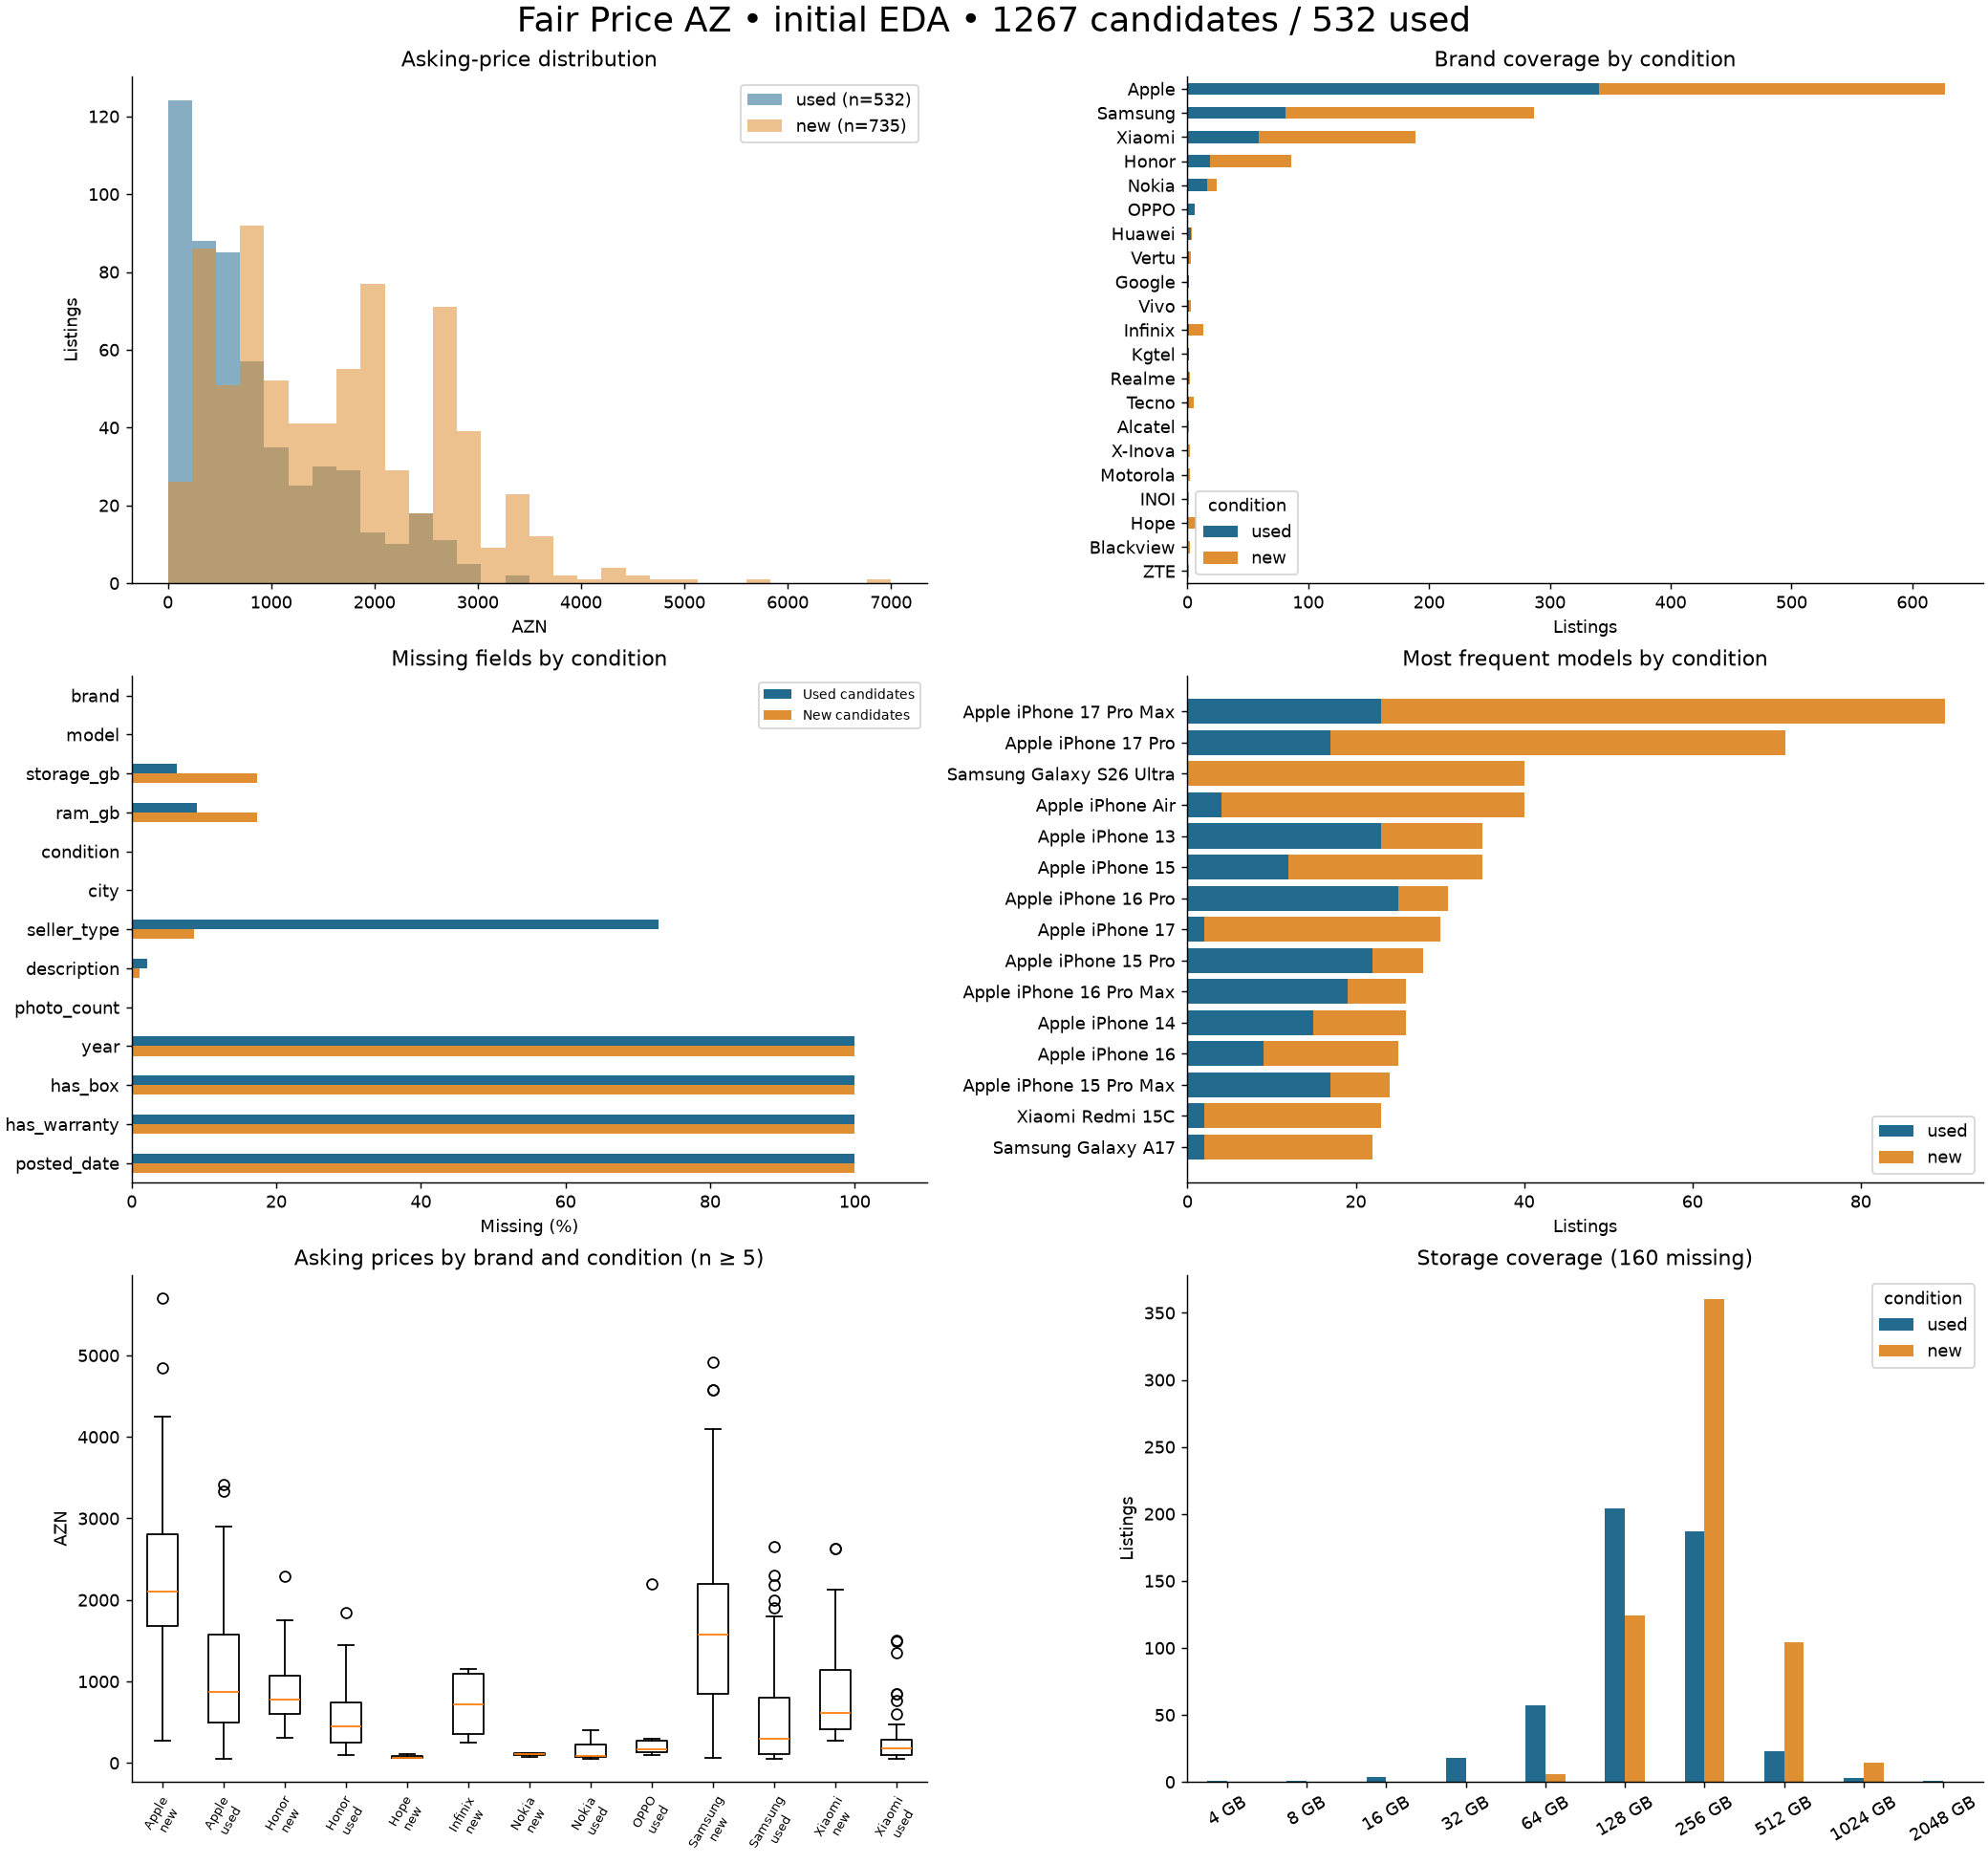

In [5]:
from IPython.display import Image, display

display(Image(filename=str(ROOT / "reports/eda/overview.png")))


## Evaluation rules

- Keep both conditions in training; include condition as a categorical feature.
- Keep duplicate groups in one partition and preserve existing test assignments.
- Fit preprocessing inside grouped cross-validation on training rows only.
- Choose among median, random forest and used-weighted forest by used-only validation MAE.
- Report used and new MAE, RMSE and signed bias separately. Mixed MAE is supplemental.
- Use 15% verdict thresholds for used phones and 5% for new phones; these are product rules.

This exploratory report includes reserved evaluation rows. Do not use its price distributions to tune the model.
Exact-text groups do not identify every duplicated device. Sparse models and condition ambiguity limit conclusions.

Run `python -m model.prepare` and `python -m model.train` from the project root to create model artifacts.
Training metrics and per-listing residuals are saved under `model/artifacts/`.
